# Data Source Recommendation: Interview vs Diary for Financial Product Recommendations


### Why Interview Data is Better for Your Use Case

#### 1. **Perfect Match for Your Requirements**
-  **Demographics**: Rich demographic variables (age, family size, region, education, employment, housing tenure)
-  **Income**: Comprehensive income data with multiple sources (wages, retirement, investments)
-  **Expenditure**: Pre-aggregated category-level spending (food, housing, transportation, healthcare, etc.)
-  **Household-Level**: Already aggregated at consumer unit level - no additional processing needed

#### 2. **Data Structure Advantages**
- **782 variables** covering all aspects needed for recommendations
- **~4,600-4,700 households per quarter** - sufficient sample size for robust modeling
- **Clean structure**: Each household = 1 row with all features
- **Lower missingness**: ~21% overall (vs diary's need for aggregation)

#### 3. **Modeling Benefits**
- **Feature Engineering**: Easier to create demographic × income × expenditure interactions
- **Segmentation**: Better for creating customer segments based on demographics + income
- **Recommendations**: Category-level spending ratios perfect for product recommendations
- **Scalability**: Smaller dataset size = faster model training and inference

### When to Use Diary Data (Supplementary)

Use diary data for:
- **Transaction-level insights**: Daily spending patterns, frequency analysis
- **Behavioral features**: Spending timing, purchase frequency, seasonality
- **Validation**: Cross-validate interview-based models
- **Deep-dive analysis**: Understanding spending within specific categories

### Recommended Architecture

```
PRIMARY: Interview Data (FMLI, MEMI, MTBI)
├── Demographics (age, family size, region, education)
├── Income (total, sources, stability)
└── Expenditure Categories (food, housing, transportation, etc.)
    ↓
FEATURE ENGINEERING
├── Demographic features
├── Income features  
├── Expenditure ratios
└── Interaction features
    ↓
MODELING
├── Customer Segmentation
├── Spending Prediction
└── Product Recommendations
    ↓
SUPPLEMENTARY: Diary Data (for validation & deep insights)
└── Transaction-level patterns
```

### Implementation Strategy

1. **Start with Interview Data** (80% of effort)
   - Build core recommendation engine
   - Create demographic × income × expenditure features
   - Develop segmentation models

2. **Enhance with Diary Data** (20% of effort)
   - Add transaction frequency features
   - Validate spending predictions
   - Refine category-level recommendations

### Key Features from Interview Data

- **Demographics**: Age, family size, region, education, employment, housing tenure
- **Income**: Total income, income sources, income quintiles, income-to-median ratio
- **Expenditure**: Category spending, expenditure ratios, total expenditure, savings rate
- **Interactions**: Age × Income, Family Size × Expenditure, Region × Category Ratios

### Conclusion

We will use interview data because:
- Rich demographics 
- Comprehensive income data  
- Category-level expenditure 
- Clean, aggregated structure 
- Sufficient sample size 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


# Consumer Expenditure Survey - Interview Data Analysis Summary & Suggested Features

## Executive Summary

This notebook analyzes Consumer Expenditure Survey (CES) 2024 Interview data for Q2, Q3, and Q4 2024. The interview survey captures household-level characteristics, income, and expenditure patterns through quarterly interviews with consumer units.

### Dataset Overview
- **Source**: CES Interview Survey 2024 (Q2-Q4)
- **Total Records**: 13,886 consumer units
- **Variables**: 782 columns covering demographics, income, and expenditure categories
- **Data Types**: Mix of float64 (489), object (178), and int64 (115) variables
- **Memory Usage**: ~200 MB

### Key Characteristics

#### 1. Sample Structure
- **Quarterly Samples**: 
  - Q2 2024: 4,673 consumer units
  - Q3 2024: 4,612 consumer units  
  - Q4 2024: 4,601 consumer units
- **Sample Stability**: Consistent sample sizes across quarters (~4,600-4,700 per quarter)
- **Unique Consumer Units**: Each NEWID appears once per quarter (cross-sectional design)

#### 2. Data Completeness
- **Missing Data Patterns**: Varies by variable type
  - Demographic variables: Generally well-populated
  - Income variables: Some missingness for non-applicable cases
  - Expenditure variables: Missing for categories not applicable to household
- **Data Quality**: High-quality survey data with minimal duplicates

#### 3. Variable Categories
- **Demographics**: Age, family size, region, urban/rural, housing tenure
- **Income**: Multiple income sources, before/after tax income
- **Expenditure**: Detailed category-level spending (food, housing, transportation, etc.)
- **Household Characteristics**: Education, employment, marital status

---

## Key Insights from Analysis

### Income Patterns
- Income distribution shows right-skewed pattern (mean > median)
- Multiple income sources contribute to total household income
- Income stability varies by source type

### Expenditure Patterns
- Major expenditure categories: Housing, Transportation, Food
- Category spending varies significantly by household characteristics
- Seasonal patterns observable in certain categories (e.g., Q4 holiday spending)

### Demographic Relationships
- Age strongly correlates with spending patterns
- Family size impacts per-capita expenditure
- Regional differences in cost of living reflected in spending

---

## Suggested Features for Financial Recommendation System

### 1. Core Demographic Features

#### Age-Based Features
- `age_group`: Categorical (18-34, 35-49, 50-64, 65+)
- `age_squared`: For non-linear age effects
- `is_senior`: Binary flag (65+)
- `is_young_adult`: Binary flag (18-34)

#### Family Composition
- `family_size`: Number of household members
- `family_size_squared`: For non-linear effects
- `has_children`: Binary (family_size > 2)
- `is_single`: Binary (family_size == 1)
- `is_couple`: Binary (family_size == 2)
- `per_capita_income`: Income / family_size
- `per_capita_expenditure`: Expenditure / family_size

#### Geographic Features
- `region`: Northeast, Midwest, South, West (one-hot encoded)
- `is_urban`: Urban vs. rural classification
- `state_code`: If available, for state-level cost of living

### 2. Income Features

#### Income Level Features
- `total_income`: Total household income before taxes
- `log_income`: Log transformation for normalization
- `income_quintile`: Quintile assignment (1-5)
- `income_decile`: Decile assignment (1-10)
- `income_percentile`: Continuous percentile rank
- `income_to_median_ratio`: Relative to median income

#### Income Source Features
- `wage_income`: Income from wages/salary
- `self_employment_income`: Self-employment earnings
- `retirement_income`: Retirement benefits
- `investment_income`: Investment returns
- `other_income`: Other income sources
- `income_diversity`: Number of income sources
- `wage_income_ratio`: Wage income / total income
- `passive_income_ratio`: (Retirement + Investment) / total income

#### Income Stability
- `income_volatility`: Coefficient of variation (if longitudinal)
- `income_trend`: Quarter-over-quarter change (if tracking same households)

### 3. Expenditure Features

#### Total Expenditure
- `total_expenditure`: Sum of all category expenditures
- `log_expenditure`: Log transformation
- `expenditure_quintile`: Quintile assignment
- `expenditure_to_income_ratio`: Spending relative to income

#### Category-Level Features
- `food_expenditure`: Total food spending
- `housing_expenditure`: Housing costs
- `transportation_expenditure`: Transportation costs
- `healthcare_expenditure`: Healthcare spending
- `entertainment_expenditure`: Entertainment spending
- `education_expenditure`: Education costs
- `apparel_expenditure`: Clothing spending

#### Category Ratios
- `food_ratio`: Food / total expenditure
- `housing_ratio`: Housing / total expenditure
- `transportation_ratio`: Transportation / total expenditure
- `healthcare_ratio`: Healthcare / total expenditure
- `entertainment_ratio`: Entertainment / total expenditure
- `essential_spending_ratio`: (Food + Housing + Healthcare) / total
- `discretionary_spending_ratio`: (Entertainment + Apparel) / total

#### Spending Patterns
- `spending_diversity`: Number of categories with non-zero spending
- `spending_concentration`: Herfindahl index of category shares
- `large_purchase_flag`: Binary (any category > threshold)
- `category_spending_rank`: Rank of spending by category

### 4. Financial Health Indicators

#### Savings Features
- `savings_amount`: Income - Expenditure
- `savings_rate`: (Income - Expenditure) / Income
- `is_positive_savings`: Binary flag
- `savings_quintile`: Savings rate quintile

#### Debt Features (if available)
- `debt_to_income_ratio`: Total debt / income
- `debt_service_ratio`: Debt payments / income
- `has_mortgage`: Binary flag
- `has_consumer_debt`: Binary flag

#### Spending Efficiency
- `expenditure_volatility`: Coefficient of variation across categories
- `spending_efficiency_score`: Custom metric combining ratios
- `budget_adherence`: If budget data available

### 5. Temporal Features

#### Quarter Indicators
- `quarter`: Q2, Q3, Q4 (one-hot encoded)
- `is_q4`: Binary flag for Q4 (holiday season)
- `quarter_number`: 2, 3, 4 (ordinal)

#### Seasonal Features
- `is_summer`: Q2-Q3 (Jul-Sep)
- `is_fall`: Q4 (Oct-Dec)
- `is_holiday_season`: Q4 flag

#### Trend Features (if longitudinal)
- `qoq_income_change`: Quarter-over-quarter income change
- `qoq_expenditure_change`: Quarter-over-quarter spending change
- `yoy_income_change`: Year-over-year income change
- `yoy_expenditure_change`: Year-over-year spending change

### 6. Interaction Features

#### Demographic × Income Interactions
- `age_x_income`: Age × Income
- `age_x_log_income`: Age × Log(Income)
- `family_size_x_income`: Family Size × Income
- `region_x_income`: Region × Income (categorical interaction)

#### Demographic × Expenditure Interactions
- `age_x_expenditure`: Age × Expenditure
- `family_size_x_expenditure`: Family Size × Expenditure
- `region_x_expenditure`: Region × Expenditure

#### Income × Expenditure Interactions
- `income_x_expenditure_ratio`: Income × (Expenditure/Income)
- `income_quintile_x_category_ratio`: Income quintile × category ratios

### 7. Derived Composite Features

#### Lifestyle Indicators
- `lifestyle_score`: Composite of discretionary spending ratios
- `financial_stress_indicator`: Based on savings rate and debt ratios
- `spending_behavior_cluster`: From clustering analysis

#### Predictive Features
- `expected_expenditure`: Predicted from income/demographics
- `expenditure_residual`: Actual - Expected expenditure
- `spending_anomaly_score`: Statistical outlier detection

### 8. Target Variables for Modeling

#### Regression Targets
- `next_quarter_expenditure`: Predict Q1 2025 spending
- `category_expenditure`: Predict spending in specific category
- `savings_rate`: Predict savings rate
- `expenditure_growth`: Predict quarter-over-quarter change

#### Classification Targets
- `high_spender`: Binary (top 25% of spenders)
- `budget_optimizer`: Binary (spending efficiency above threshold)
- `category_focus`: Multi-class (primary spending category)
- `financial_health_tier`: Ordinal (Poor, Fair, Good, Excellent)

---

## Modeling Recommendations

### Feature Engineering Pipeline
1. **Missing Data Handling**
   - Impute missing income with median by demographic group
   - Create "missing" category for categorical variables
   - Use domain knowledge for expenditure missingness (often means $0)

2. **Transformations**
   - Log transform: Income, Expenditure, Category spending
   - Standardize: All numerical features
   - One-hot encode: Categorical variables
   - Target encode: High-cardinality categoricals

3. **Feature Selection**
   - Remove highly correlated features (correlation > 0.95)
   - Use feature importance from tree-based models
   - Consider PCA for high-dimensional category features

### Model Types

#### For Spending Prediction
- **Regression**: Random Forest, Gradient Boosting, XGBoost
- **Time Series**: LSTM, Prophet (if longitudinal)
- **Ensemble**: Stack multiple models

#### For Recommendations
- **Collaborative Filtering**: Find similar households
- **Content-Based**: Use demographic/income features
- **Hybrid**: Combine collaborative + content-based
- **Clustering**: K-means, DBSCAN for segmentation
- **Association Rules**: Market basket analysis for spending patterns

### Evaluation Strategy
- **Time-based Split**: Train on Q2-Q3, validate on Q4
- **Metrics**: 
  - Regression: RMSE, MAE, R², MAPE
  - Classification: Precision, Recall, F1, AUC-ROC
  - Business: Recommendation acceptance rate, cost savings

### Model Interpretability
- Use SHAP values for feature importance
- Create partial dependence plots
- Generate rule-based explanations
- Build decision trees for transparency

---

## Next Steps

1. **Feature Engineering**: Implement all suggested features
2. **Exploratory Analysis**: Deep dive into feature relationships
3. **Model Development**: Build predictive models
4. **Validation**: Test on holdout quarter
5. **Deployment**: Create recommendation API
6. **Monitoring**: Track model performance over time
7. **Iteration**: Refine features based on model insights

In [2]:
# Define directories
data_dir = Path('./data/intrvw24')
output_dir = Path('./data/output-interview')
output_dir.mkdir(parents=True, exist_ok=True)

# Define quarters (focusing on 2024)
quarters_2024 = ['242', '243', '244']  # Q2, Q3, Q4 2024

print(f"Data directory: {data_dir}")
print(f"Output directory: {output_dir}")
print(f"Analyzing quarters: {quarters_2024}")

Data directory: data/intrvw24
Output directory: data/output-interview
Analyzing quarters: ['242', '243', '244']


In [3]:
def load_quarterly_files(file_prefix, quarters, data_dir):
    """Load and combine quarterly files"""
    dfs = []
    for quarter in quarters:
        file_path = data_dir / f'{file_prefix}{quarter}.csv'
        if file_path.exists():
            df = pd.read_csv(file_path)
            df['quarter'] = quarter
            dfs.append(df)
            print(f"✓ Loaded {file_prefix}{quarter}.csv: {len(df):,} records")
        else:
            print(f"✗ File not found: {file_path}")
    
    if dfs:
        combined = pd.concat(dfs, ignore_index=True)
        print(f"\n✓ Combined {file_prefix} data: {len(combined):,} total records")
        return combined
    return None

# Load FMLI files
print("Loading FMLI (Family Characteristics) files...\n")
fmli = load_quarterly_files('fmli', quarters_2024, data_dir)

Loading FMLI (Family Characteristics) files...

✓ Loaded fmli242.csv: 4,673 records
✓ Loaded fmli243.csv: 4,612 records
✓ Loaded fmli244.csv: 4,601 records

✓ Combined fmli data: 13,886 total records


In [4]:
# Dataset overview
print(f"Dataset Shape: {fmli.shape[0]:,} rows × {fmli.shape[1]} columns")
print(f"Memory Usage: {fmli.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nData Types:")
print(fmli.dtypes.value_counts())

Dataset Shape: 13,886 rows × 782 columns
Memory Usage: 200.56 MB

Data Types:
float64    489
object     178
int64      115
Name: count, dtype: int64


In [5]:
# View first few rows
fmli.head()

,NEWID,DIRACC,DIRACC_,AGE_REF,AGE_REF_,AGE2,AGE2_,AS_COMP1,AS_C_MP1,AS_COMP2,AS_C_MP2,AS_COMP3,AS_C_MP3,AS_COMP4,AS_C_MP4,AS_COMP5,AS_C_MP5,BATHRMQ,BATHRMQ_,BEDROOMQ,BEDR_OMQ,BLS_URBN,BUILDING,BUIL_ING,CUTENURE,CUTE_URE,EARNCOMP,EARN_OMP,EDUC_REF,EDUC0REF,EDUCA2,EDUCA2_,FAM_SIZE,FAM__IZE,FAM_TYPE,FAM__YPE,FGOVRETX,FGOV_ETX,FINCBTAX,FINCBT_X,FINDRETX,FIND_ETX,FINLWT21,FJSSDEDX,FJSS_EDX,FPRIPENX,FPRI_ENX,FRRDEDX,FRRDEDX_,FRRETIRX,FRRE_IRX,FSALARYX,FSAL_RYX,FSSIX,FSSIX_,INC_HRS1,INC__RS1,INC_HRS2,INC__RS2,INC_RANK,INC__ANK,INCNONW1,INCN_NW1,INCNONW2,INCN_NW2,INCOMEY1,INCO_EY1,INCOMEY2,INCO_EY2,INCWEEK1,INCW_EK1,INCWEEK2,INCW_EK2,MISCTAXX,MISC_AXX,LUMPSUMX,LUMP_UMX,MARITAL1,MARI_AL1,NO_EARNR,NO_E_RNR,NONINCMX,NONI_CMX,NUM_AUTO,NUM__UTO,OCCUCOD1,OCCU_OD1,OCCUCOD2,OCCU_OD2,OTHRINCX,OTHR_NCX,PERSLT18,PERS_T18,PERSOT64,PERS_T64,POPSIZE,PRINEARN,PRIN_ARN,QINTRVMO,QINTRVYR,RACE2,RACE2_,REF_RACE,REF__ACE,REGION,RENTEQVX,RENT_QVX,SEX_REF,SEX_REF_,SEX2,SEX2_,SMSASTAT,ST_HOUS,ST_HOUS_,VEHQ,VEHQ_,WELFAREX,WELF_REX,WTREP01,WTREP02,WTREP03,WTREP04,WTREP05,WTREP06,WTREP07,WTREP08,WTREP09,WTREP10,WTREP11,WTREP12,WTREP13,WTREP14,WTREP15,WTREP16,WTREP17,WTREP18,WTREP19,WTREP20,WTREP21,WTREP22,WTREP23,WTREP24,WTREP25,WTREP26,WTREP27,WTREP28,WTREP29,WTREP30,WTREP31,WTREP32,WTREP33,WTREP34,WTREP35,WTREP36,WTREP37,WTREP38,WTREP39,WTREP40,WTREP41,WTREP42,WTREP43,WTREP44,TOTEXPPQ,TOTEXPCQ,FDHOMEPQ,FDHOMECQ,FDAWAYPQ,FDAWAYCQ,FDXMAPPQ,FDXMAPCQ,FDMAPPQ,FDMAPCQ,ALCBEVPQ,ALCBEVCQ,HOUSPQ,HOUSCQ,SHELTPQ,SHELTCQ,OWNDWEPQ,OWNDWECQ,MRTINTPQ,MRTINTCQ,PROPTXPQ,PROPTXCQ,MRPINSPQ,MRPINSCQ,RENDWEPQ,RENDWECQ,RNTXRPPQ,RNTXRPCQ,RNTAPYPQ,RNTAPYCQ,OTHLODPQ,OTHLODCQ,UTILPQ,UTILCQ,NTLGASPQ,NTLGASCQ,ELCTRCPQ,ELCTRCCQ,ALLFULPQ,ALLFULCQ,FULOILPQ,FULOILCQ,OTHFLSPQ,OTHFLSCQ,TELEPHPQ,TELEPHCQ,WATRPSPQ,WATRPSCQ,HOUSOPPQ,HOUSOPCQ,DOMSRVPQ,DOMSRVCQ,DMSXCCPQ,DMSXCCCQ,BBYDAYPQ,BBYDAYCQ,OTHHEXPQ,OTHHEXCQ,HOUSEQPQ,HOUSEQCQ,TEXTILPQ,TEXTILCQ,FURNTRPQ,FURNTRCQ,FLRCVRPQ,FLRCVRCQ,MAJAPPPQ,MAJAPPCQ,SMLAPPPQ,SMLAPPCQ,MISCEQPQ,MISCEQCQ,GIFTAPPQ,CHLDAPPQ,ADLTAPPQ,APPARPQ,GIFTAPCQ,CHLDAPCQ,ADLTAPCQ,APPARCQ,TRANSPQ,TRANSCQ,CARTKNPQ,CARTKNCQ,CARTKUPQ,CARTKUCQ,OTHVEHPQ,OTHVEHCQ,GASMOPQ,GASMOCQ,VEHFINPQ,VEHFINCQ,MAINRPPQ,MAINRPCQ,VEHINSPQ,VEHINSCQ,VRNTLOPQ,VRNTLOCQ,PUBTRAPQ,PUBTRACQ,TRNTRPPQ,TRNTRPCQ,TRNOTHPQ,TRNOTHCQ,HEALTHPQ,HEALTHCQ,HLTHINPQ,HLTHINCQ,MEDSRVPQ,MEDSRVCQ,PREDRGPQ,PREDRGCQ,MEDSUPPQ,MEDSUPCQ,ENTERTPQ,ENTERTCQ,FEEADMPQ,FEEADMCQ,TVRDIOPQ,TVRDIOCQ,OTHEQPPQ,OTHEQPCQ,PETTOYPQ,PETTOYCQ,OTHENTPQ,OTHENTCQ,PERSCAPQ,PERSCACQ,READPQ,READCQ,EDUCAPQ,EDUCACQ,TOBACCPQ,TOBACCCQ,MISCPQ,MISCCQ,MISC1PQ,MISC1CQ,MISC2PQ,MISC2CQ,CASHCOPQ,CASHCOCQ,PERINSPQ,PERINSCQ,LIFINSPQ,LIFINSCQ,RETPENPQ,RETPENCQ,HH_CU_Q,HH_CU_Q_,HHID,HHID_,CHILDAGE,CHIL_AGE,STATE,ERANKH,ERANKH_,TOTEX4PQ,TOTEX4CQ,MISCX4PQ,MISCX4CQ,VEHQL,VEHQL_,NUM_TVAN,NUM__VAN,TTOTALP,TTOTALC,TFOODTOP,TFOODTOC,TFOODAWP,TFOODAWC,TFOODHOP,TFOODHOC,TALCBEVP,TALCBEVC,TOTHRLOP,TOTHRLOC,TTRANPRP,TTRANPRC,TGASMOTP,TGASMOTC,TVRENTLP,TVRENTLC,TCARTRKP,TCARTRKC,TOTHVHRP,TOTHVHRC,TOTHTREP,TOTHTREC,TTRNTRIP,TTRNTRIC,TFAREP,TFAREC,TAIRFARP,TAIRFARC,TOTHFARP,TOTHFARC,TLOCALTP,TLOCALTC,TENTRMNP,TENTRMNC,TFEESADP,TFEESADC,TOTHENTP,TOTHENTC,OWNVACP,OWNVACC,VOTHRLOP,VOTHRLOC,VMISCHEP,VMISCHEC,UTILOWNP,UTILOWNC,VFUELOIP,VFUELOIC,VOTHRFLP,VOTHRFLC,VELECTRP,VELECTRC,VNATLGAP,VNATLGAC,VWATERPP,VWATERPC,MRTPRNOP,MRTPRNOC,UTILRNTP,UTILRNTC,RFUELOIP,RFUELOIC,ROTHRFLP,ROTHRFLC,RELECTRP,RELECTRC,RNATLGAP,RNATLGAC,RWATERPP,RWATERPC,ETOTALP,ETOTALC,ETOTAPX4,ETOTACX4,EHOUSNGP,EHOUSNGC,ESHELTRP,ESHELTRC,EOWNDWLP,EOWNDWLC,EOTHLODP,EOTHLODC,EMRTPNOP,EMRTPNOC,EMRTPNVP,EMRTPNVC,ETRANPTP,ETRANPTC,EVEHPURP,EVEHPURC,ECARTKNP,ECARTKNC,ECARTKUP,ECARTKUC,EOTHVEHP,EOTHVEHC,EENTRMTP,EENTRMTC,EOTHENTP,EOTHENTC,EENTMSCP,EENTMSCC,EMISCELP,EMISCELC,EMISCMTP,EMISCMTC,UNISTRQ,UNISTRQ_,ERECVEHC,ERECVEHP,WELFREBX,WELF_EBX,LUMPSUMB,LUMP_UMB,LMPSUMBX,LMPS_MBX,OTHRINCB,OTHR_NCB,OTRINCBX,OTRI_CBX,INCLASS2,INCL_SS2,CUID,INTERI,HORREF1,HORREF1_,HORREF2,HORREF2_,ERANKHM,ERANKHM_,FGOVRETM,FGOV_ETM,FINCBTXM,FINC

In [6]:
# Check column names
print("Available columns:")
print(fmli.columns.tolist())

Available columns:
['NEWID', 'DIRACC', 'DIRACC_', 'AGE_REF', 'AGE_REF_', 'AGE2', 'AGE2_', 'AS_COMP1', 'AS_C_MP1', 'AS_COMP2', 'AS_C_MP2', 'AS_COMP3', 'AS_C_MP3', 'AS_COMP4', 'AS_C_MP4', 'AS_COMP5', 'AS_C_MP5', 'BATHRMQ', 'BATHRMQ_', 'BEDROOMQ', 'BEDR_OMQ', 'BLS_URBN', 'BUILDING', 'BUIL_ING', 'CUTENURE', 'CUTE_URE', 'EARNCOMP', 'EARN_OMP', 'EDUC_REF', 'EDUC0REF', 'EDUCA2', 'EDUCA2_', 'FAM_SIZE', 'FAM__IZE', 'FAM_TYPE', 'FAM__YPE', 'FGOVRETX', 'FGOV_ETX', 'FINCBTAX', 'FINCBT_X', 'FINDRETX', 'FIND_ETX', 'FINLWT21', 'FJSSDEDX', 'FJSS_EDX', 'FPRIPENX', 'FPRI_ENX', 'FRRDEDX', 'FRRDEDX_', 'FRRETIRX', 'FRRE_IRX', 'FSALARYX', 'FSAL_RYX', 'FSSIX', 'FSSIX_', 'INC_HRS1', 'INC__RS1', 'INC_HRS2', 'INC__RS2', 'INC_RANK', 'INC__ANK', 'INCNONW1', 'INCN_NW1', 'INCNONW2', 'INCN_NW2', 'INCOMEY1', 'INCO_EY1', 'INCOMEY2', 'INCO_EY2', 'INCWEEK1', 'INCW_EK1', 'INCWEEK2', 'INCW_EK2', 'MISCTAXX', 'MISC_AXX', 'LUMPSUMX', 'LUMP_UMX', 'MARITAL1', 'MARI_AL1', 'NO_EARNR', 'NO_E_RNR', 'NONINCMX', 'NONI_CMX', 'NUM_AUT

In [ ]:
# Missing data analysis (before handling)
missing_pct = (fmli.isnull().sum() / len(fmli) * 100).sort_values(ascending=False)
print("Top 20 columns with missing data:")
print(missing_pct.head(20))

In [7]:
# =============================================================================
# MISSING VALUES HANDLING
# Strategy: expenditure missing = $0, income = median, categorical = "MISSING"
# =============================================================================

fmli_clean = fmli.copy()

# 1. Drop columns with >95% missing (structural NAs, add little value)
MISSING_THRESHOLD = 0.95
cols_to_drop = (fmli_clean.isnull().sum() / len(fmli_clean)) > MISSING_THRESHOLD
dropped_cols = cols_to_drop[cols_to_drop].index.tolist()
fmli_clean = fmli_clean.drop(columns=dropped_cols)
print(f"Dropped {len(dropped_cols)} columns with >95% missing")

# 2. Expenditure variables: missing often means $0 (category not applicable)
expend_patterns = ['PQ', 'CQ', 'EXPPQ', 'EXPCQ', 'FD', 'HOUS', 'TRAN', 'HEALTH', 'ENTERT', 'EDUC', 'APPAR']
expend_cols = [c for c in fmli_clean.columns if any(p in c for p in expend_patterns) and fmli_clean[c].dtype in ['float64', 'int64']]
fmli_clean[expend_cols] = fmli_clean[expend_cols].fillna(0)
print(f"Imputed {len(expend_cols)} expenditure columns with 0")

# 3. Income variables: impute with median
income_keywords = ['INC', 'INCOME', 'FINC', 'SALARY', 'WAGE', 'RETIR', 'INVEST', 'RENT', 'TAX']
income_cols = [c for c in fmli_clean.columns if any(k in c for k in income_keywords) and c not in expend_cols 
               and fmli_clean[c].dtype in ['float64', 'int64']]
income_imputed = sum(1 for c in income_cols if fmli_clean[c].isnull().any())
for col in income_cols:
    if fmli_clean[col].isnull().any():
        fmli_clean[col] = fmli_clean[col].fillna(fmli_clean[col].median())
print(f"Imputed {income_imputed} income columns with median")

# 4. Other numerical columns: median imputation
num_cols = fmli_clean.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if fmli_clean[col].isnull().any():
        fmli_clean[col] = fmli_clean[col].fillna(fmli_clean[col].median())

# 5. Categorical columns: fill with "MISSING"
cat_cols = fmli_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    if fmli_clean[col].isnull().any():
        fmli_clean[col] = fmli_clean[col].fillna('MISSING').astype(str)

fmli = fmli_clean
remaining_missing = fmli.isnull().sum().sum()
print(f"\n✓ Missing value handling complete. Remaining missing values: {remaining_missing}")

Top 20 columns with missing data:
OTRINCBX   100.00
OTHSTYR     99.98
WELFREBX    99.96
WHLFYR      99.96
OTHRINCB    99.93
OTHLONB     99.93
OTHLONBX    99.93
LMPSUMBX    99.92
LUMPSUMB    99.92
ROYESTB     99.90
ROYESTBX    99.90
OTHLYRBX    99.88
OTHLNYRB    99.88
STDNTYR     99.88
STOCKYR     99.86
OTHSYRBX    99.83
IRAYR       99.83
OTHSTYRB    99.83
OTHASTB     99.83
OTHASTBX    99.83
dtype: float64


In [8]:
# Define key variables
demographic_vars = {
    'AGE_REF': 'Age of reference person',
    'REGION': 'Geographic region',
    'FAM_SIZE': 'Family size',
    'CUTENURE': 'Housing tenure',
    'EDUC_REF': 'Education level',
    'SEX_REF': 'Sex of reference person',
}

income_vars = {
    'FINCBTXM': 'Income before taxes',
    'FINCATXM': 'Income after taxes',
}

expenditure_vars = {
    'TOTEXPPQ': 'Total expenditure',
    'FOODPQ': 'Food expenditure',
    'HOUSPQ': 'Housing expenditure',
    'TRANSPQ': 'Transportation expenditure',
    'HEALTHPQ': 'Healthcare expenditure',
    'ENTERTPQ': 'Entertainment expenditure',
    'APPARPQ': 'Apparel expenditure',
    'EDUCAPQ': 'Education expenditure',
}

# Check which variables are available
available_demo = {k: v for k, v in demographic_vars.items() if k in fmli.columns}
available_income = {k: v for k, v in income_vars.items() if k in fmli.columns}
available_expend = {k: v for k, v in expenditure_vars.items() if k in fmli.columns}

print(f"Demographics: {len(available_demo)}/{len(demographic_vars)} available")
print(f"Income: {len(available_income)}/{len(income_vars)} available")
print(f"Expenditure: {len(available_expend)}/{len(expenditure_vars)} available")

Demographics: 6/6 available
Income: 1/2 available
Expenditure: 7/8 available


## Demographics

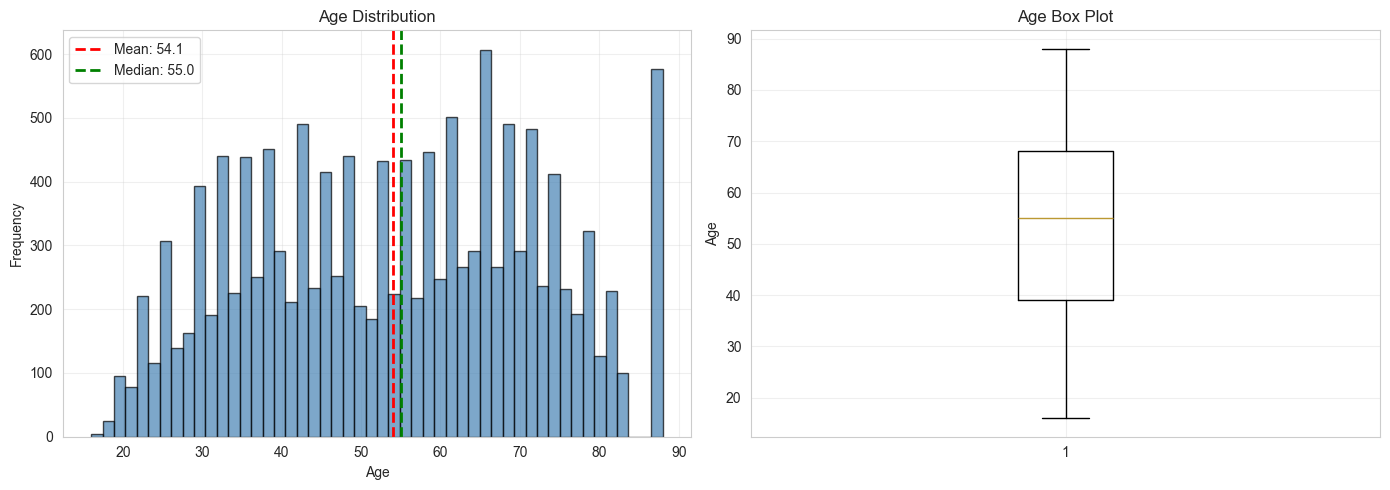

Age Statistics:
count   13886.00
mean       54.07
std        17.90
min        16.00
25%        39.00
50%        55.00
75%        68.00
max        88.00
Name: AGE_REF, dtype: float64


In [10]:
# Age Distribution
if 'AGE_REF' in fmli.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    age_data = fmli['AGE_REF'].dropna()
    
    # Histogram
    axes[0].hist(age_data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].axvline(age_data.mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Mean: {age_data.mean():.1f}')
    axes[0].axvline(age_data.median(), color='green', linestyle='--', 
                    linewidth=2, label=f'Median: {age_data.median():.1f}')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Age Distribution')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot
    axes[1].boxplot(age_data, vert=True)
    axes[1].set_ylabel('Age')
    axes[1].set_title('Age Box Plot')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Age Statistics:")
    print(age_data.describe())

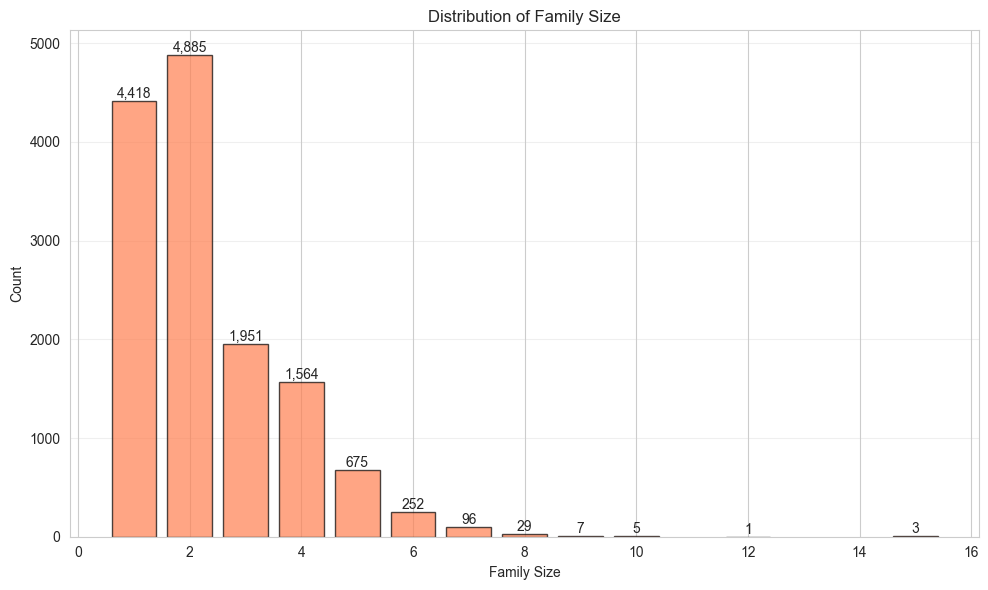

In [11]:
# Family Size Distribution
if 'FAM_SIZE' in fmli.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    fam_size_counts = fmli['FAM_SIZE'].value_counts().sort_index()
    bars = ax.bar(fam_size_counts.index, fam_size_counts.values, 
                  color='coral', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Family Size')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Family Size')
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

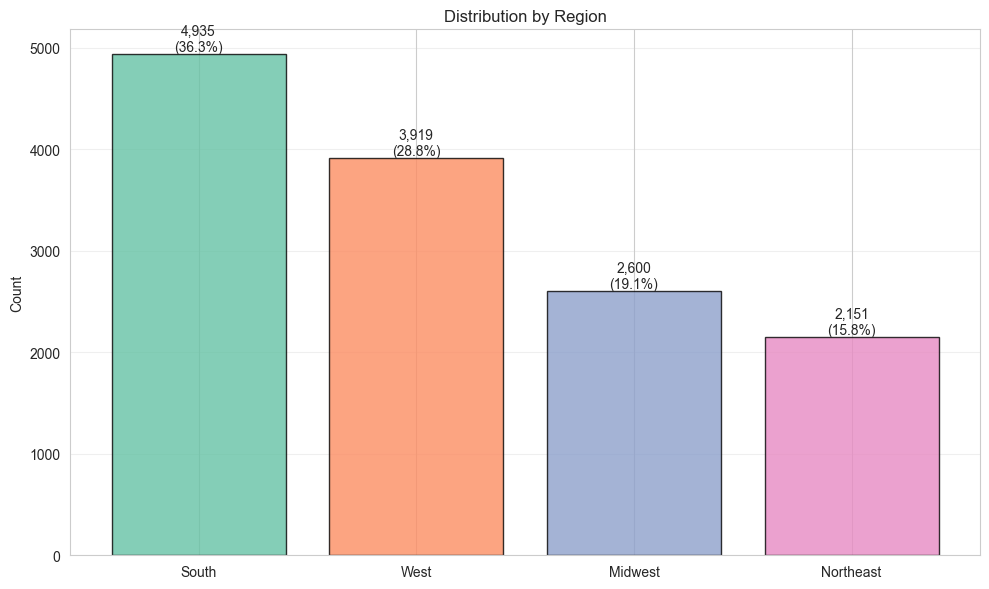

In [12]:
# Regional Distribution
if 'REGION' in fmli.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    region_counts = fmli['REGION'].value_counts()
    region_labels = {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'}
    region_names = [region_labels.get(r, f'Region {r}') for r in region_counts.index]
    
    colors = sns.color_palette("Set2", len(region_counts))
    bars = ax.bar(region_names, region_counts.values, color=colors, 
                  edgecolor='black', alpha=0.8)
    ax.set_ylabel('Count')
    ax.set_title('Distribution by Region')
    ax.grid(axis='y', alpha=0.3)
    
    total = region_counts.sum()
    for bar, count in zip(bars, region_counts.values):
        height = bar.get_height()
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({pct:.1f}%)', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

## Income

In [13]:
# Income Distribution
if 'FINCBTXM' in fmli.columns:
    income_data = fmli['FINCBTXM'].dropna()
    income_data = income_data[income_data > 0]
    
    print("Income Statistics:")
    print(income_data.describe())
    print(f"\nMean: ${income_data.mean():,.2f}")
    print(f"Median: ${income_data.median():,.2f}")

Income Statistics:
count    13852.00
mean    106645.86
std     105334.13
min          1.00
25%      36000.00
50%      75000.00
75%     139610.15
max     963420.00
Name: FINCBTXM, dtype: float64

Mean: $106,645.86
Median: $75,000.00


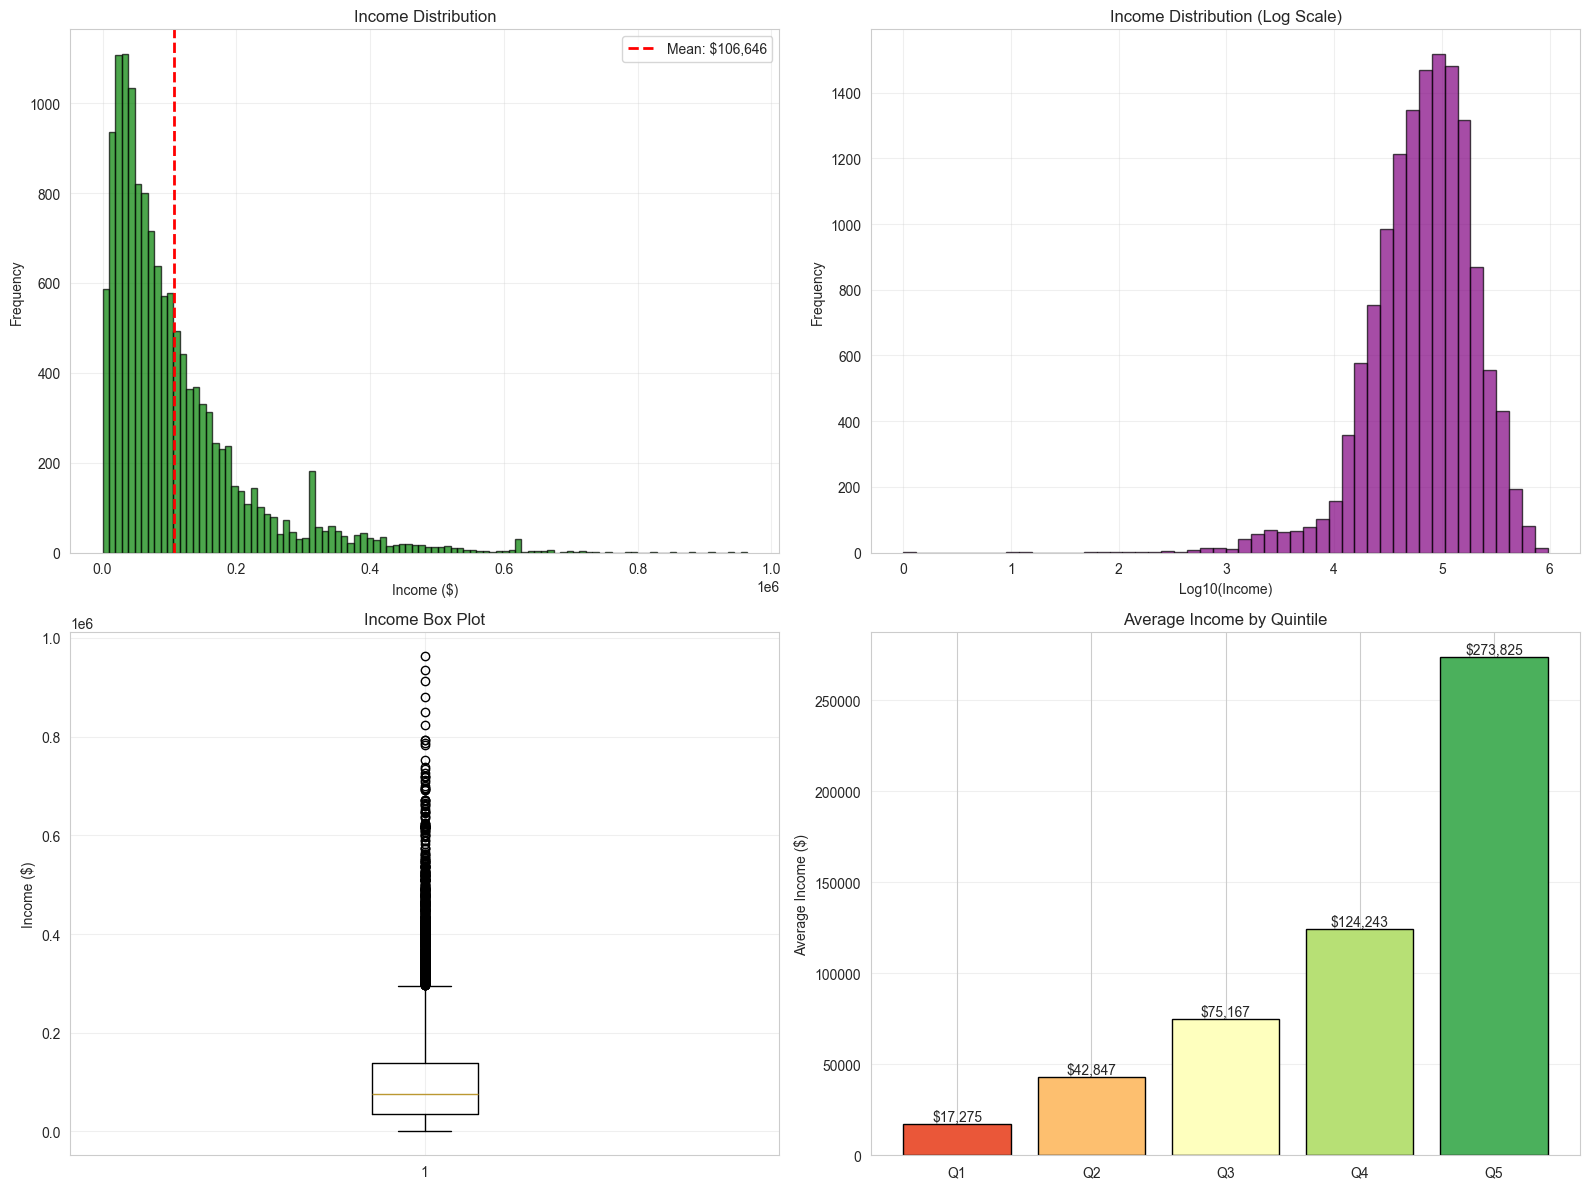

In [14]:
# Income visualizations
if 'FINCBTXM' in fmli.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Histogram
    axes[0, 0].hist(income_data, bins=100, edgecolor='black', alpha=0.7, color='green')
    axes[0, 0].axvline(income_data.mean(), color='red', linestyle='--', 
                       linewidth=2, label=f'Mean: ${income_data.mean():,.0f}')
    axes[0, 0].set_xlabel('Income ($)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Income Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Log scale
    axes[0, 1].hist(np.log10(income_data), bins=50, edgecolor='black', 
                    alpha=0.7, color='purple')
    axes[0, 1].set_xlabel('Log10(Income)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Income Distribution (Log Scale)')
    axes[0, 1].grid(alpha=0.3)
    
    # Box plot
    axes[1, 0].boxplot(income_data, vert=True)
    axes[1, 0].set_ylabel('Income ($)')
    axes[1, 0].set_title('Income Box Plot')
    axes[1, 0].grid(alpha=0.3)
    
    # Income quintiles
    quintiles = pd.qcut(income_data, q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    quintile_means = income_data.groupby(quintiles).mean()
    
    bars = axes[1, 1].bar(range(len(quintile_means)), quintile_means.values,
                          color=sns.color_palette("RdYlGn", 5), edgecolor='black')
    axes[1, 1].set_xticks(range(len(quintile_means)))
    axes[1, 1].set_xticklabels(quintile_means.index)
    axes[1, 1].set_ylabel('Average Income ($)')
    axes[1, 1].set_title('Average Income by Quintile')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars, quintile_means.values):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'${value:,.0f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

## Expenditure

In [15]:
# Total Expenditure Statistics
if 'TOTEXPPQ' in fmli.columns:
    expend_data = fmli['TOTEXPPQ'].dropna()
    expend_data = expend_data[expend_data > 0]
    
    print("Expenditure Statistics:")
    print(expend_data.describe())
    print(f"\nMean: ${expend_data.mean():,.2f}")
    print(f"Median: ${expend_data.median():,.2f}")

Expenditure Statistics:
count    13886.00
mean     13445.59
std      14066.89
min         92.83
25%       5227.75
50%       9401.88
75%      16787.34
max     314014.05
Name: TOTEXPPQ, dtype: float64

Mean: $13,445.59
Median: $9,401.88


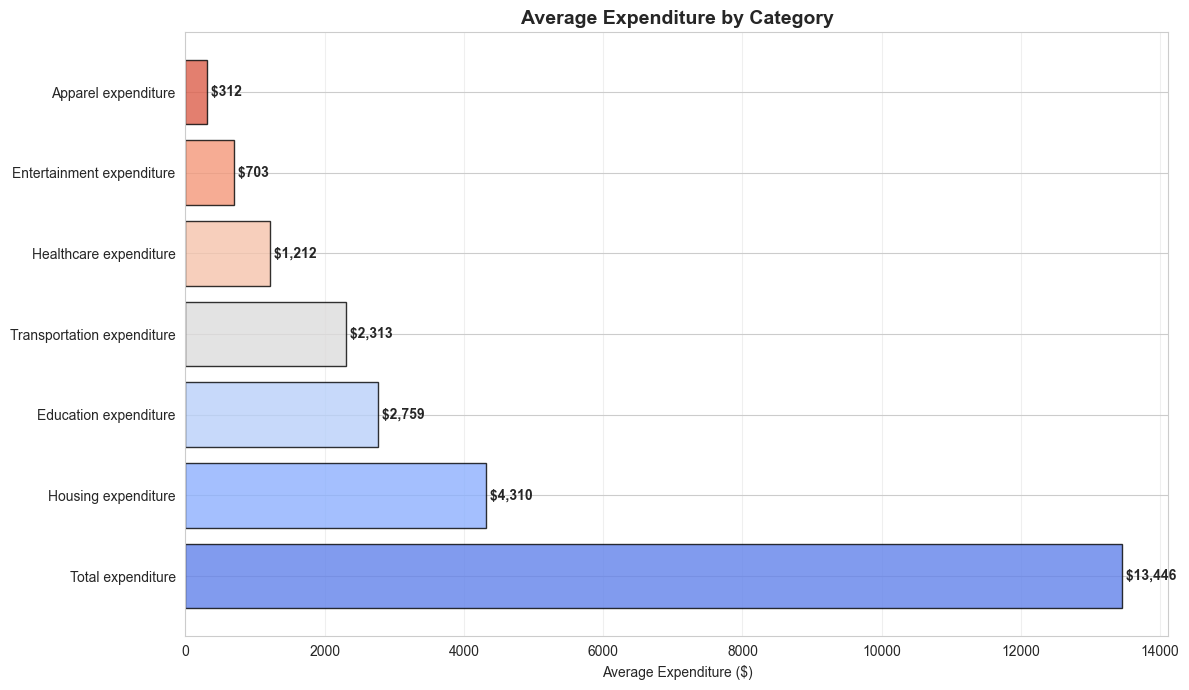

In [16]:
# Expenditure by Category
if available_expend:
    category_means = {}
    for var, name in available_expend.items():
        data = fmli[var].dropna()
        data = data[data > 0]
        category_means[name] = data.mean()
    
    category_means = dict(sorted(category_means.items(), key=lambda x: x[1], reverse=True))
    
    fig, ax = plt.subplots(figsize=(12, 7))
    colors = sns.color_palette("coolwarm", len(category_means))
    bars = ax.barh(list(category_means.keys()), list(category_means.values()),
                   color=colors, edgecolor='black', alpha=0.8)
    ax.set_xlabel('Average Expenditure ($)')
    ax.set_title('Average Expenditure by Category', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    for bar, value in zip(bars, category_means.values()):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
               f' ${value:,.0f}', ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

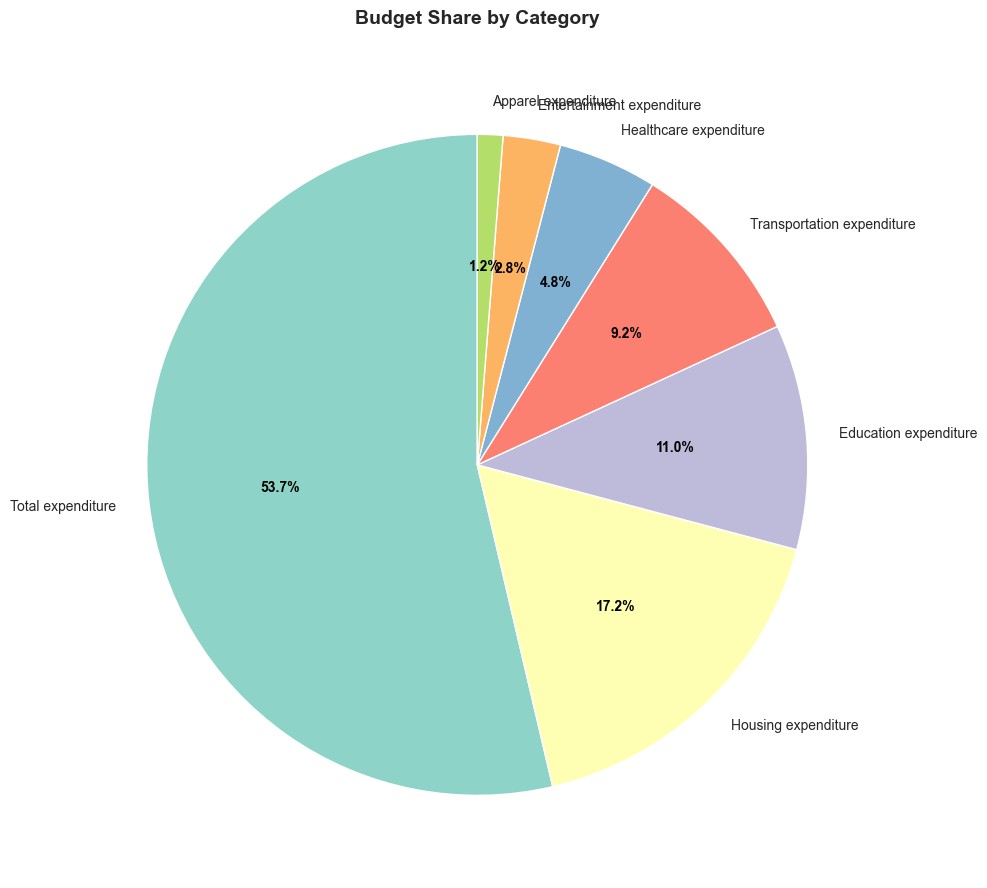

In [17]:
# Budget Shares (Pie Chart)
if 'TOTEXPPQ' in fmli.columns and available_expend:
    fig, ax = plt.subplots(figsize=(10, 10))
    
    total_mean = fmli['TOTEXPPQ'].dropna().mean()
    shares = {name: (value / total_mean * 100) for name, value in category_means.items()}
    
    colors = sns.color_palette("Set3", len(shares))
    wedges, texts, autotexts = ax.pie(shares.values(), labels=shares.keys(),
                                       autopct='%1.1f%%', startangle=90,
                                       colors=colors)
    
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
    
    ax.set_title('Budget Share by Category', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

## income vs expenditure

Correlation: 0.503


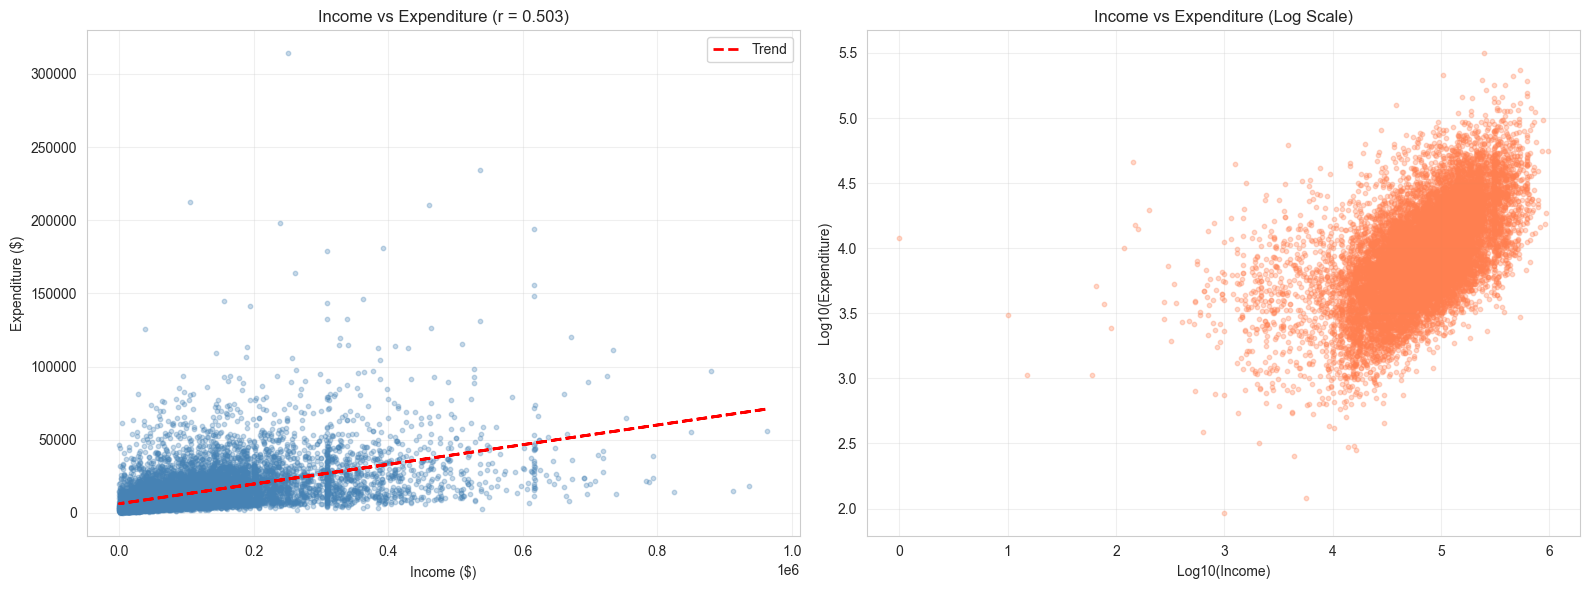

In [18]:
# Income vs Expenditure Scatter Plot
if 'FINCBTXM' in fmli.columns and 'TOTEXPPQ' in fmli.columns:
    analysis_df = fmli[['FINCBTXM', 'TOTEXPPQ']].dropna()
    analysis_df = analysis_df[(analysis_df['FINCBTXM'] > 0) & (analysis_df['TOTEXPPQ'] > 0)]
    
    correlation = analysis_df['FINCBTXM'].corr(analysis_df['TOTEXPPQ'])
    print(f"Correlation: {correlation:.3f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Regular scale
    axes[0].scatter(analysis_df['FINCBTXM'], analysis_df['TOTEXPPQ'], 
                   alpha=0.3, s=10, color='steelblue')
    axes[0].set_xlabel('Income ($)')
    axes[0].set_ylabel('Expenditure ($)')
    axes[0].set_title(f'Income vs Expenditure (r = {correlation:.3f})')
    axes[0].grid(alpha=0.3)
    
    # Add trend line
    z = np.polyfit(analysis_df['FINCBTXM'], analysis_df['TOTEXPPQ'], 1)
    p = np.poly1d(z)
    axes[0].plot(analysis_df['FINCBTXM'], p(analysis_df['FINCBTXM']), 
                "r--", linewidth=2, label='Trend')
    axes[0].legend()
    
    # Log scale
    axes[1].scatter(np.log10(analysis_df['FINCBTXM']), 
                   np.log10(analysis_df['TOTEXPPQ']),
                   alpha=0.3, s=10, color='coral')
    axes[1].set_xlabel('Log10(Income)')
    axes[1].set_ylabel('Log10(Expenditure)')
    axes[1].set_title('Income vs Expenditure (Log Scale)')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [19]:
## income vs expenditure by quintile

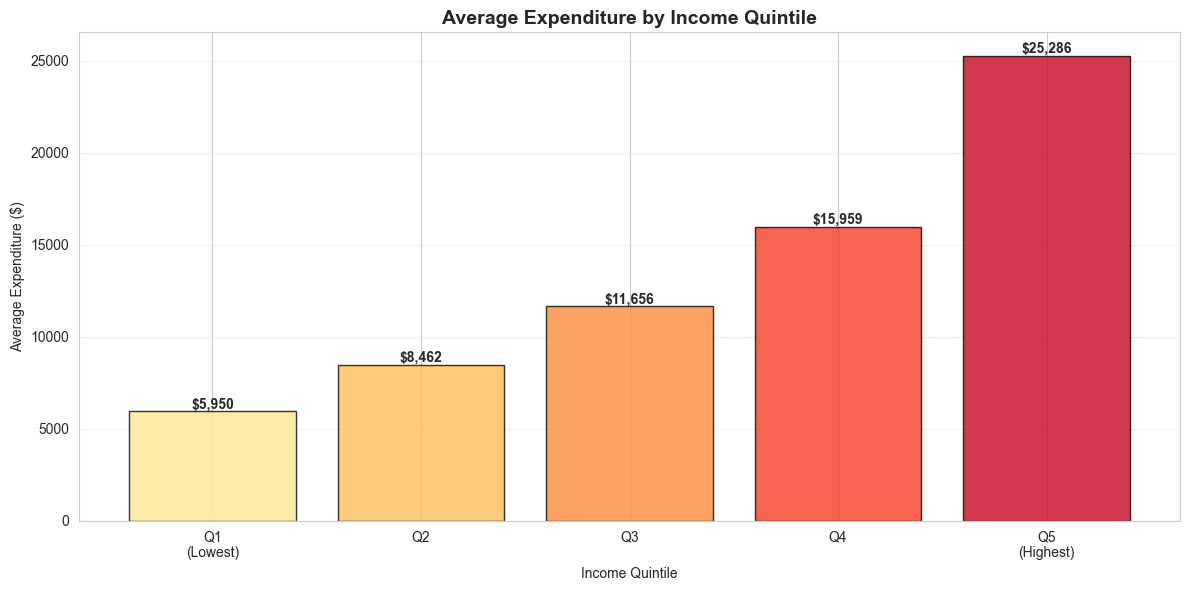

Average Expenditure by Quintile:
  Q1
(Lowest): $5,950.25
  Q2: $8,461.97
  Q3: $11,655.54
  Q4: $15,959.22
  Q5
(Highest): $25,286.14


In [20]:
# Expenditure by Income Quintile
if 'FINCBTXM' in fmli.columns and 'TOTEXPPQ' in fmli.columns:
    quintile_df = fmli[['FINCBTXM', 'TOTEXPPQ']].dropna()
    quintile_df = quintile_df[quintile_df['FINCBTXM'] > 0]
    
    quintile_df['quintile'] = pd.qcut(quintile_df['FINCBTXM'], 
                                      q=5, 
                                      labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Highest)'])
    
    quintile_means = quintile_df.groupby('quintile')['TOTEXPPQ'].mean()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = sns.color_palette("YlOrRd", 5)
    bars = ax.bar(range(len(quintile_means)), quintile_means.values,
                  color=colors, edgecolor='black', alpha=0.8)
    ax.set_xticks(range(len(quintile_means)))
    ax.set_xticklabels(quintile_means.index)
    ax.set_ylabel('Average Expenditure ($)')
    ax.set_xlabel('Income Quintile')
    ax.set_title('Average Expenditure by Income Quintile', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for bar, value in zip(bars, quintile_means.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("Average Expenditure by Quintile:")
    for q, value in quintile_means.items():
        print(f"  {q}: ${value:,.2f}")

In [ ]:
# summary table
summary_data = []

if 'FINCBTXM' in fmli.columns:
    income_clean = fmli['FINCBTXM'].dropna()
    income_clean = income_clean[income_clean > 0]
    summary_data.append({
        'Variable': 'Income Before Taxes',
        'Mean': f"${income_clean.mean():,.2f}",
        'Median': f"${income_clean.median():,.2f}",
        'Std Dev': f"${income_clean.std():,.2f}",
        'N': f"{len(income_clean):,}"
    })

if 'TOTEXPPQ' in fmli.columns:
    expend_clean = fmli['TOTEXPPQ'].dropna()
    expend_clean = expend_clean[expend_clean > 0]
    summary_data.append({
        'Variable': 'Total Expenditure',
        'Mean': f"${expend_clean.mean():,.2f}",
        'Median': f"${expend_clean.median():,.2f}",
        'Std Dev': f"${expend_clean.std():,.2f}",
        'N': f"{len(expend_clean):,}"
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,Variable,Mean,Median,Std Dev,N
0,Income Before Taxes,"$106,645.86","$75,000.00","$105,334.13","13,852"
1,Total Expenditure,"$13,445.59","$9,401.88","$14,066.89","13,886"


In [ ]:
print("\n" + "="*80)
print("SECTION 4: DUPLICATE RECORDS ANALYSIS")
print("="*80)

# Check for complete duplicates
total_rows = len(fmli)
duplicate_rows = fmli.duplicated().sum()
duplicate_pct = (duplicate_rows / total_rows * 100)

print(f"\nCOMPLETE DUPLICATE ROWS:")
print(f"  Total rows: {total_rows:,}")
print(f"  Duplicate rows: {duplicate_rows:,}")
print(f"  Percentage: {duplicate_pct:.2f}%")

# Check for duplicates based on key identifier (NEWID)
if 'NEWID' in fmli.columns:
    print(f"\nDUPLICATES BASED ON NEWID (Consumer Unit ID):")
    newid_duplicates = fmli['NEWID'].duplicated().sum()
    unique_newids = fmli['NEWID'].nunique()
    print(f"  Total records: {total_rows:,}")
    print(f"  Unique consumer units (NEWID): {unique_newids:,}")
    print(f"  Duplicate NEWIDs: {newid_duplicates:,}")
    print(f"  Expected: Multiple records per NEWID (quarterly interviews)")
    
    # Distribution of records per NEWID
    newid_counts = fmli['NEWID'].value_counts()
    print(f"\n  Records per Consumer Unit:")
    print(f"    Min: {newid_counts.min()}")
    print(f"    Max: {newid_counts.max()}")
    print(f"    Mean: {newid_counts.mean():.2f}")
    print(f"    Median: {newid_counts.median():.0f}")
    
    # Show distribution
    records_distribution = newid_counts.value_counts().sort_index()
    print(f"\n  Distribution of interviews per consumer unit:")
    for n_records, count in records_distribution.items():
        pct = count / len(newid_counts) * 100
        print(f"    {n_records} interview(s): {count:,} consumer units ({pct:.1f}%)")
    
    # Check for true duplicates (same NEWID and same quarter)
    if 'quarter' in fmli.columns:
        print(f"\nTRUE DUPLICATES (Same NEWID + Same Quarter):")
        true_duplicates = fmli.duplicated(subset=['NEWID', 'quarter']).sum()
        true_dup_pct = (true_duplicates / total_rows * 100)
        print(f"  Duplicate NEWID+Quarter combinations: {true_duplicates:,} ({true_dup_pct:.2f}%)")
        
        if true_duplicates > 0:
            print(f"WARNING: Found {true_duplicates} true duplicate records!")
            # Show examples
            dup_mask = fmli.duplicated(subset=['NEWID', 'quarter'], keep=False)
            dup_examples = fmli[dup_mask][['NEWID', 'quarter']].head(10)
            print("\n  Example duplicate NEWID+Quarter combinations:")
            print(dup_examples.to_string(index=False))
        else:
            print(f"  ✓ No true duplicates found (expected)")


SECTION 4: DUPLICATE RECORDS ANALYSIS

COMPLETE DUPLICATE ROWS:
  Total rows: 13,886
  Duplicate rows: 0
  Percentage: 0.00%

DUPLICATES BASED ON NEWID (Consumer Unit ID):
  Total records: 13,886
  Unique consumer units (NEWID): 13,886
  Duplicate NEWIDs: 0
  Expected: Multiple records per NEWID (quarterly interviews)

  Records per Consumer Unit:
    Min: 1
    Max: 1
    Mean: 1.00
    Median: 1

  Distribution of interviews per consumer unit:
    1 interview(s): 13,886 consumer units (100.0%)

TRUE DUPLICATES (Same NEWID + Same Quarter):
  Duplicate NEWID+Quarter combinations: 0 (0.00%)
  ✓ No true duplicates found (expected)


In [23]:
# Create duplicate summary table
duplicate_summary = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Complete Duplicate Rows',
        'Complete Duplicate %',
        'Unique Consumer Units (NEWID)',
        'Records per Consumer Unit (avg)',
        'True Duplicates (NEWID+Quarter)',
        'True Duplicates %'
    ],
    'Value': [
        f"{total_rows:,}",
        f"{duplicate_rows:,}",
        f"{duplicate_pct:.2f}%",
        f"{unique_newids:,}" if 'NEWID' in fmli.columns else "N/A",
        f"{newid_counts.mean():.2f}" if 'NEWID' in fmli.columns else "N/A",
        f"{true_duplicates:,}" if 'NEWID' in fmli.columns and 'quarter' in fmli.columns else "N/A",
        f"{true_dup_pct:.2f}%" if 'NEWID' in fmli.columns and 'quarter' in fmli.columns else "N/A"
    ]
})

print("\n" + "-"*80)
print("DUPLICATE RECORDS SUMMARY TABLE:")
print("-"*80)
print(duplicate_summary.to_string(index=False))

# Save duplicate summary
duplicate_summary.to_csv(output_dir / 'duplicate_records_summary.csv', index=False)
print(f"\n✓ Saved: duplicate_records_summary.csv")



--------------------------------------------------------------------------------
DUPLICATE RECORDS SUMMARY TABLE:
--------------------------------------------------------------------------------
                         Metric  Value
                  Total Records 13,886
        Complete Duplicate Rows      0
           Complete Duplicate %  0.00%
  Unique Consumer Units (NEWID) 13,886
Records per Consumer Unit (avg)   1.00
True Duplicates (NEWID+Quarter)      0
              True Duplicates %  0.00%

✓ Saved: duplicate_records_summary.csv


QUARTERLY ANALYSIS - CONSUMER EXPENDITURE SURVEY 2024
Analyzing: Q2, Q3, Q4 2024
Output directory: data/output-quarterly

SECTION 1: LOADING QUARTERLY DATA
✓ Loaded Q2 2024: 4,673 records, 783 columns
✓ Loaded Q3 2024: 4,612 records, 783 columns
✓ Loaded Q4 2024: 4,601 records, 783 columns

✓ Combined dataset: 13,886 total records

SECTION 2: SAMPLE SIZE ANALYSIS BY QUARTER

Q2 2024 (Apr-Jun):
  Total records: 4,673
  Unique consumer units: 4,673
  Variables: 783

Q3 2024 (Jul-Sep):
  Total records: 4,612
  Unique consumer units: 4,612
  Variables: 783

Q4 2024 (Oct-Dec):
  Total records: 4,601
  Unique consumer units: 4,601
  Variables: 783

✓ Saved: 01_quarterly_sample_sizes.csv
✓ Saved: 01_viz_sample_sizes.png

SECTION 3: DEMOGRAPHIC COMPARISON BY QUARTER

✓ Saved: 02_age_by_quarter.csv

AGE STATISTICS BY QUARTER:
          Quarter  Mean_Age  Median_Age  Std_Dev  Min  Max
Q2 2024 (Apr-Jun)     54.04       55.00    17.71   16   88
Q3 2024 (Jul-Sep)     53.82       54.00    18.01   16